# 082: thomas_dill k=26 vs k=27 — What queries are lost?

Identifies queries where `hp_thomas_dill k=26` detects family members (FAM > 0) but `k=27` does not, and vice versa. Breaks down lost/gained queries by SCOPe class and family to see if specific structural classes are disproportionately affected.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import gc
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns

sys.path.append(str(Path.cwd()))
from scope_kmerseek_utils import (
    EVAL_USECOLS,
    SCOPE_CLASS_DESCRIPTIONS,
    add_composite_scores_scope,
    eval_tsv_to_rocx,
    recompute_bonferroni,
    sensitivity_stats,
)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")
plt.rcParams["figure.dpi"] = 120

SWEEP_DIR = Path.home() / "data/scope/results-hp-alphabet-sweep"
SCOPE_DOM_PATH = (
    Path.home() / "data/scope/results-scope-pvalue-benchmark/scope_domains.tsv"
)
BONF_THRESHOLD = 0.05
LABEL = "hp_thomas_dill"
K_A, K_B = 26, 27  # compare k=26 (reference) vs k=27

## 1. Load SCOPe domain metadata

In [3]:
scope_domains = pl.read_csv(SCOPE_DOM_PATH, separator="\t")
# Exclude class e (multidomain)
scope_domains = scope_domains.filter(pl.col("scop_class") != "e")
print(f"SCOPe domains (class e excluded): {scope_domains.height:,}")
print(scope_domains.head(3))

SCOPe domains (class e excluded): 14,873
shape: (3, 8)
┌───────────┬─────────┬────────────┬───────────┬────────────┬────────────┬────────────┬────────────┐
│ domain_id ┆ scop_id ┆ scop_class ┆ scop_fold ┆ scop_super ┆ scop_famil ┆ protein_na ┆ species    │
│ ---       ┆ ---     ┆ ---        ┆ ---       ┆ family     ┆ y          ┆ me         ┆ ---        │
│ str       ┆ str     ┆ str        ┆ str       ┆ ---        ┆ ---        ┆ ---        ┆ str        │
│           ┆         ┆            ┆           ┆ str        ┆ str        ┆ str        ┆            │
╞═══════════╪═════════╪════════════╪═══════════╪════════════╪════════════╪════════════╪════════════╡
│ d1dlwa_   ┆ a.1.1.1 ┆ a          ┆ a.1       ┆ a.1.1      ┆ a.1.1.1    ┆ Protozoan/ ┆ Ciliate    │
│           ┆         ┆            ┆           ┆            ┆            ┆ bacterial  ┆ (Parameciu │
│           ┆         ┆            ┆           ┆            ┆            ┆ hemoglobin ┆ m          │
│           ┆         ┆            ┆

## 2. Load and process eval files for k=26 and k=27

In [4]:
def load_rocx(label: str, k: int) -> pl.DataFrame:
    path = SWEEP_DIR / f"scope_eval.{label}.k{k}.tsv.gz"
    if not path.exists():
        path = SWEEP_DIR / f"scope_eval.{label}.k{k}.tsv"
    ev = pl.read_csv(path, separator="\t")
    ev = add_composite_scores_scope(ev)
    ev = recompute_bonferroni(ev)
    ev_filt = ev.filter(pl.col("bonferroni_correct") < BONF_THRESHOLD)
    rocx = eval_tsv_to_rocx(
        ev_filt, score_col="jaccard", ascending=False, exclude_gray_zone=True
    )
    del ev, ev_filt
    gc.collect()
    return rocx


rocx_a = load_rocx(LABEL, K_A)
rocx_b = load_rocx(LABEL, K_B)

print(f"k={K_A}: {rocx_a.height:,} queries in ROCX")
print(f"k={K_B}: {rocx_b.height:,} queries in ROCX")
print()
_, _, fam_a = sensitivity_stats(rocx_a, "FAM")
_, _, fam_b = sensitivity_stats(rocx_b, "FAM")
print(f"FAM AUC  k={K_A}: {fam_a:.4f}")
print(f"FAM AUC  k={K_B}: {fam_b:.4f}")

k=26: 683 queries in ROCX
k=27: 530 queries in ROCX

FAM AUC  k=26: 0.8465
FAM AUC  k=27: 0.9035


## 3. Identify lost / gained / retained / never-detected queries

- **lost**: FAM > 0 at k=26, FAM = 0 at k=27
- **gained**: FAM = 0 at k=26, FAM > 0 at k=27
- **retained**: FAM > 0 at both
- **never**: FAM = 0 at both

In [5]:
# Outer-join on NAME to compare FAM sensitivity per query
cmp = (
    rocx_a.select(["NAME", "SCOP", "FAM", "SFAM", "FOLD"])
    .rename({"FAM": f"FAM_{K_A}", "SFAM": f"SFAM_{K_A}", "FOLD": f"FOLD_{K_A}"})
    .join(
        rocx_b.select(["NAME", "FAM", "SFAM", "FOLD"]).rename(
            {"FAM": f"FAM_{K_B}", "SFAM": f"SFAM_{K_B}", "FOLD": f"FOLD_{K_B}"}
        ),
        on="NAME",
        how="full",
        coalesce=True,
    )
    .with_columns(
        [
            pl.col(f"FAM_{K_A}").fill_null(0.0),
            pl.col(f"FAM_{K_B}").fill_null(0.0),
        ]
    )
    .with_columns(
        pl.when((pl.col(f"FAM_{K_A}") > 0) & (pl.col(f"FAM_{K_B}") == 0))
        .then(pl.lit("lost"))
        .when((pl.col(f"FAM_{K_A}") == 0) & (pl.col(f"FAM_{K_B}") > 0))
        .then(pl.lit("gained"))
        .when((pl.col(f"FAM_{K_A}") > 0) & (pl.col(f"FAM_{K_B}") > 0))
        .then(pl.lit("retained"))
        .otherwise(pl.lit("never"))
        .alias("status")
    )
)

counts = cmp.group_by("status").len().sort("len", descending=True)
print(counts)

n_lost = int(cmp.filter(pl.col("status") == "lost").height)
n_gained = int(cmp.filter(pl.col("status") == "gained").height)
n_retained = int(cmp.filter(pl.col("status") == "retained").height)
n_never = int(cmp.filter(pl.col("status") == "never").height)

print(f"\nLost (k={K_A}→k={K_B}):  {n_lost}")
print(f"Gained (k={K_A}→k={K_B}): {n_gained}")
print(f"Retained:   {n_retained}")
print(f"Never:      {n_never}")

shape: (4, 2)
┌──────────┬─────┐
│ status   ┆ len │
│ ---      ┆ --- │
│ str      ┆ u32 │
╞══════════╪═════╡
│ retained ┆ 472 │
│ lost     ┆ 115 │
│ never    ┆ 86  │
│ gained   ┆ 10  │
└──────────┴─────┘

Lost (k=26→k=27):  115
Gained (k=26→k=27): 10
Retained:   472
Never:      86


## 4. Join with SCOPe domain metadata

In [6]:
cmp_ann = cmp.join(
    scope_domains.select(
        [
            "domain_id",
            "scop_class",
            "scop_fold",
            "scop_superfamily",
            "scop_family",
            "protein_name",
        ]
    ),
    left_on="NAME",
    right_on="domain_id",
    how="left",
)

# Fallback: extract class letter from SCOP ID (e.g. "a.1.1.1" → "a") for unmatched queries
cmp_ann = cmp_ann.with_columns(
    pl.coalesce(
        [
            pl.col("scop_class"),
            pl.col("SCOP").str.slice(0, 1),
        ]
    ).alias("scop_class")
)

unmatched = cmp_ann.filter(pl.col("scop_class").is_null()).height
print(f"Queries without SCOPe annotation: {unmatched}")
print(cmp_ann.head(3))

Queries without SCOPe annotation: 0
shape: (3, 14)
┌─────────┬──────────┬────────┬─────────┬───┬───────────┬──────────────┬─────────────┬─────────────┐
│ NAME    ┆ SCOP     ┆ FAM_26 ┆ SFAM_26 ┆ … ┆ scop_fold ┆ scop_superfa ┆ scop_family ┆ protein_nam │
│ ---     ┆ ---      ┆ ---    ┆ ---     ┆   ┆ ---       ┆ mily         ┆ ---         ┆ e           │
│ str     ┆ str      ┆ f64    ┆ f64     ┆   ┆ str       ┆ ---          ┆ str         ┆ ---         │
│         ┆          ┆        ┆         ┆   ┆           ┆ str          ┆             ┆ str         │
╞═════════╪══════════╪════════╪═════════╪═══╪═══════════╪══════════════╪═════════════╪═════════════╡
│ d1aa6a2 ┆ c.81.1.1 ┆ 1.0    ┆ 0.0     ┆ … ┆ c.81      ┆ c.81.1       ┆ c.81.1.1    ┆ Formate deh │
│         ┆          ┆        ┆         ┆   ┆           ┆              ┆             ┆ ydrogenase  │
│         ┆          ┆        ┆         ┆   ┆           ┆              ┆             ┆ H           │
│ d1aoea_ ┆ c.71.1.1 ┆ 1.0    ┆ 0.0     

## 5. SCOPe class breakdown of lost / gained / retained

In [7]:
class_status = (
    cmp_ann.filter(pl.col("scop_class").is_not_null())
    .group_by(["scop_class", "status"])
    .len()
    .sort(["scop_class", "status"])
)

# Pivot for display
class_pivot = (
    class_status.pivot(
        index="scop_class", on="status", values="len", aggregate_function="sum"
    )
    .fill_null(0)
    .sort("scop_class")
)

# Add description
class_pivot = class_pivot.with_columns(
    pl.col("scop_class").replace(SCOPE_CLASS_DESCRIPTIONS).alias("class_name")
)

print(class_pivot)

shape: (7, 6)
┌────────────┬────────┬──────┬───────┬──────────┬─────────────────────────────────┐
│ scop_class ┆ gained ┆ lost ┆ never ┆ retained ┆ class_name                      │
│ ---        ┆ ---    ┆ ---  ┆ ---   ┆ ---      ┆ ---                             │
│ str        ┆ u32    ┆ u32  ┆ u32   ┆ u32      ┆ str                             │
╞════════════╪════════╪══════╪═══════╪══════════╪═════════════════════════════════╡
│ a          ┆ 2      ┆ 14   ┆ 17    ┆ 61       ┆ All alpha proteins              │
│ b          ┆ 0      ┆ 13   ┆ 12    ┆ 63       ┆ All beta proteins               │
│ c          ┆ 5      ┆ 53   ┆ 35    ┆ 209      ┆ Alpha and beta proteins (a/b) … │
│ d          ┆ 3      ┆ 31   ┆ 14    ┆ 111      ┆ Alpha and beta proteins (a+b) … │
│ e          ┆ 0      ┆ 2    ┆ 6     ┆ 18       ┆ Multi-domain proteins (alpha a… │
│ f          ┆ 0      ┆ 1    ┆ 2     ┆ 6        ┆ Membrane and cell surface prot… │
│ g          ┆ 0      ┆ 1    ┆ 0     ┆ 4        ┆ Small protei

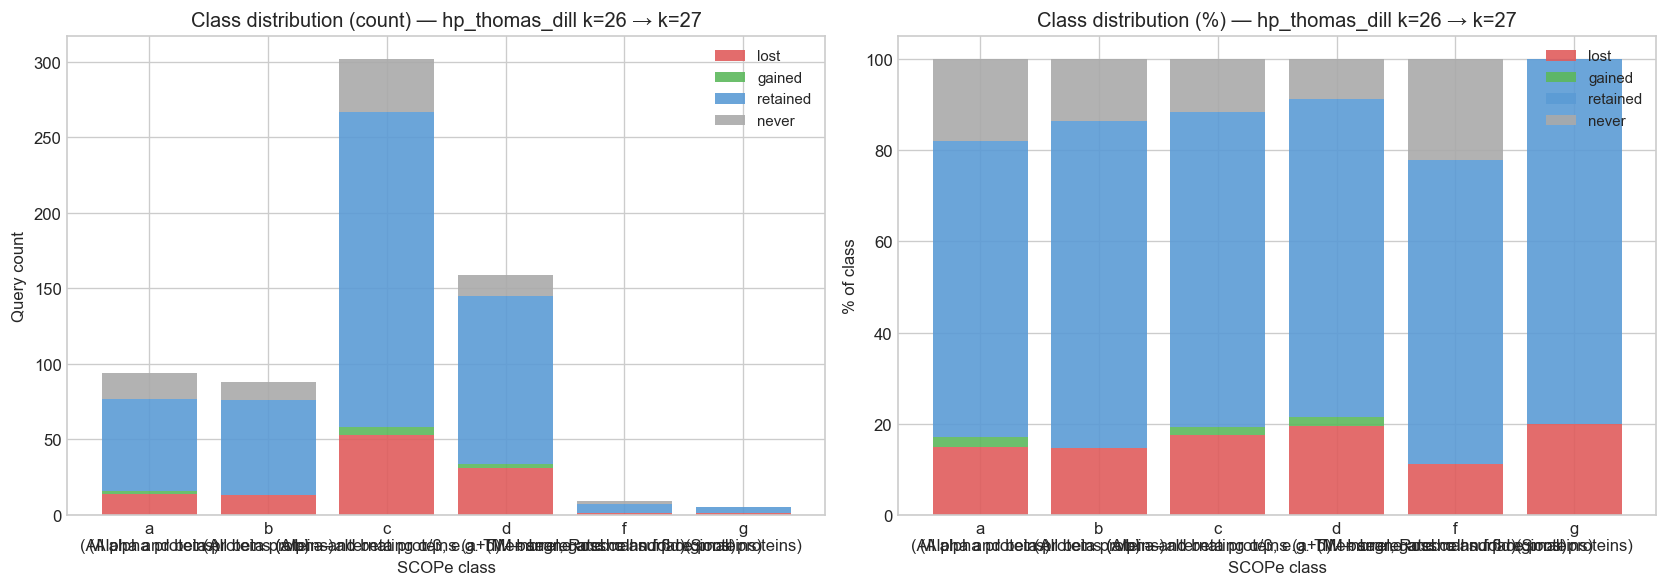

In [8]:
STATUSES = ["lost", "gained", "retained", "never"]
COLORS = {
    "lost": "#e05c5c",
    "gained": "#5cb85c",
    "retained": "#5b9bd5",
    "never": "#aaaaaa",
}

classes = sorted(cmp_ann["scop_class"].drop_nulls().unique().to_list())
classes = [c for c in classes if c != "e"]
desc = [SCOPE_CLASS_DESCRIPTIONS.get(c, c) for c in classes]
xlabels = [f"{c}\n({d})" for c, d in zip(classes, desc)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, normalize in zip(axes, [False, True]):
    bottoms = np.zeros(len(classes))
    for status in STATUSES:
        vals = np.array(
            [
                (
                    int(class_pivot.filter(pl.col("scop_class") == c)[status][0])
                    if class_pivot.filter(pl.col("scop_class") == c).height > 0
                    and status in class_pivot.columns
                    else 0
                )
                for c in classes
            ],
            dtype=float,
        )
        if normalize:
            totals = np.array(
                [
                    sum(
                        (
                            int(class_pivot.filter(pl.col("scop_class") == c)[s][0])
                            if class_pivot.filter(pl.col("scop_class") == c).height > 0
                            and s in class_pivot.columns
                            else 0
                        )
                        for s in STATUSES
                    )
                    for c in classes
                ],
                dtype=float,
            )
            totals = np.where(totals == 0, 1, totals)
            vals = vals / totals * 100
        ax.bar(
            xlabels, vals, bottom=bottoms, color=COLORS[status], label=status, alpha=0.9
        )
        bottoms += vals

    ax.set_xlabel("SCOPe class")
    ax.set_ylabel("% of class" if normalize else "Query count")
    ax.set_title(
        f"Class distribution (%) — {LABEL} k={K_A} → k={K_B}"
        if normalize
        else f"Class distribution (count) — {LABEL} k={K_A} → k={K_B}"
    )
    if normalize:
        ax.set_ylim(0, 105)
    ax.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

## 6. Lost queries: FAM sensitivity drop

In [9]:
# Also look at queries that RETAINED detection but with lower FAM
retained = cmp_ann.filter(pl.col("status") == "retained")
retained = retained.with_columns(
    (pl.col(f"FAM_{K_B}") - pl.col(f"FAM_{K_A}")).alias("fam_delta")
)

# Summary statistics
print(f"=== FAM sensitivity delta for retained queries (k={K_B} - k={K_A}) ===")
print(f"  n_retained = {retained.height:,}")
deltas = retained["fam_delta"].to_numpy()
print(f"  mean delta = {deltas.mean():.4f}")
print(f"  median delta = {np.median(deltas):.4f}")
print(f"  queries where k={K_B} is better: {(deltas > 0).sum():,}")
print(f"  queries where k={K_B} is worse:  {(deltas < 0).sum():,}")
print(f"  queries unchanged:                {(deltas == 0).sum():,}")

=== FAM sensitivity delta for retained queries (k=27 - k=26) ===
  n_retained = 472
  mean delta = 0.0120
  median delta = 0.0000
  queries where k=27 is better: 13
  queries where k=27 is worse:  0
  queries unchanged:                459


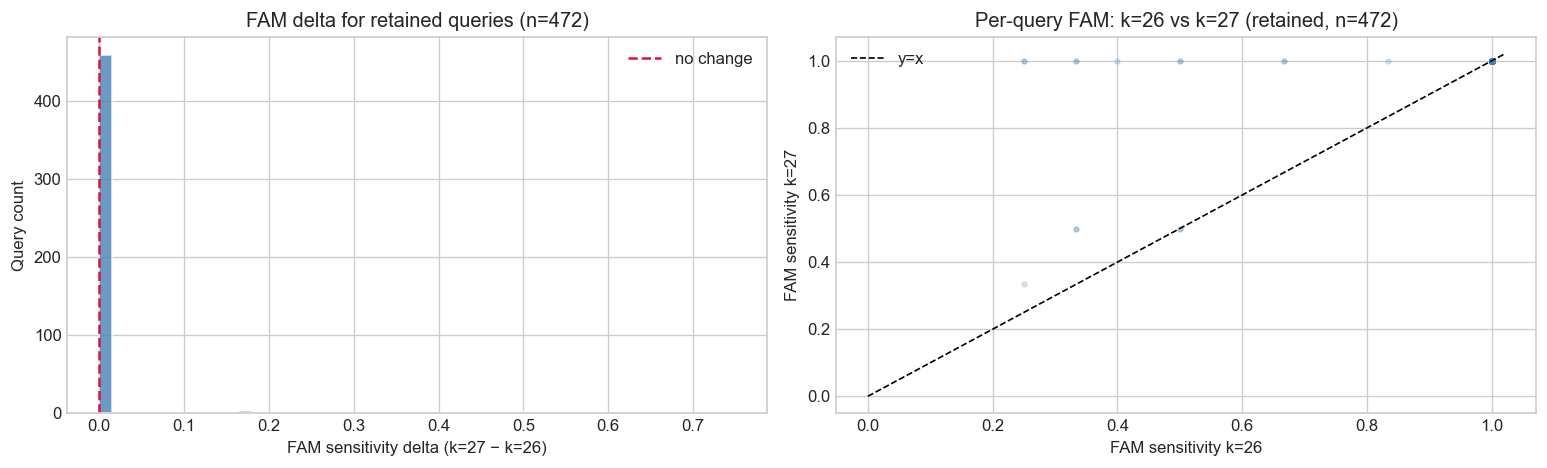

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: FAM delta distribution for retained
ax = axes[0]
ax.hist(deltas, bins=50, color="steelblue", alpha=0.8, edgecolor="white")
ax.axvline(0, color="crimson", lw=1.5, ls="--", label="no change")
ax.set_xlabel(f"FAM sensitivity delta (k={K_B} − k={K_A})")
ax.set_ylabel("Query count")
ax.set_title(f"FAM delta for retained queries (n={retained.height:,})")
ax.legend()

# Right: scatter FAM_26 vs FAM_27 for retained
ax = axes[1]
x = retained[f"FAM_{K_A}"].to_numpy()
y = retained[f"FAM_{K_B}"].to_numpy()
ax.scatter(x, y, alpha=0.2, s=8, color="steelblue")
lim = max(x.max(), y.max()) * 1.02
ax.plot([0, lim], [0, lim], "k--", lw=1, label="y=x")
ax.set_xlabel(f"FAM sensitivity k={K_A}")
ax.set_ylabel(f"FAM sensitivity k={K_B}")
ax.set_title(f"Per-query FAM: k={K_A} vs k={K_B} (retained, n={retained.height:,})")
ax.legend()

plt.tight_layout()
plt.show()

## 7. Top lost families

In [11]:
lost_df = cmp_ann.filter(pl.col("status") == "lost")

# Group by family
lost_by_fam = (
    lost_df.filter(pl.col("scop_family").is_not_null())
    .group_by(["scop_class", "scop_fold", "scop_superfamily", "scop_family"])
    .agg(
        [
            pl.len().alias("n_lost"),
            pl.col(f"FAM_{K_A}").mean().alias(f"mean_FAM_{K_A}"),
            pl.col("protein_name").first().alias("protein_name"),
        ]
    )
    .sort("n_lost", descending=True)
)

print(f"Total lost queries: {n_lost}")
print(f"Families with at least 1 lost query: {lost_by_fam.height}")
print()
print("=== Top 20 families by number of lost queries ===")
print(lost_by_fam.head(20).to_pandas().to_string(index=False))

Total lost queries: 115
Families with at least 1 lost query: 59

=== Top 20 families by number of lost queries ===
scop_class scop_fold scop_superfamily scop_family  n_lost  mean_FAM_26                               protein_name
         c       c.2            c.2.1     c.2.1.0       9          1.0                          automated matches
         c      c.94           c.94.1    c.94.1.0       6          1.0                          automated matches
         c      c.67           c.67.1    c.67.1.0       5          1.0                          automated matches
         d      d.58           d.58.7    d.58.7.0       5          1.0                          automated matches
         a     a.104          a.104.1   a.104.1.0       3          1.0                          automated matches
         d     d.211          d.211.1   d.211.1.1       2          1.0                            I-kappa-B-alpha
         d      d.79           d.79.3    d.79.3.2       2          1.0               Ce

In [12]:
# Top gained families for comparison
gained_df = cmp_ann.filter(pl.col("status") == "gained")
gained_by_fam = (
    gained_df.filter(pl.col("scop_family").is_not_null())
    .group_by(["scop_class", "scop_fold", "scop_superfamily", "scop_family"])
    .agg(
        [
            pl.len().alias("n_gained"),
            pl.col(f"FAM_{K_B}").mean().alias(f"mean_FAM_{K_B}"),
            pl.col("protein_name").first().alias("protein_name"),
        ]
    )
    .sort("n_gained", descending=True)
)

print(f"Total gained queries: {n_gained}")
print(f"Families with at least 1 gained query: {gained_by_fam.height}")
print()
print("=== Top 20 families by number of gained queries ===")
print(gained_by_fam.head(20).to_pandas().to_string(index=False))

Total gained queries: 10
Families with at least 1 gained query: 8

=== Top 20 families by number of gained queries ===
scop_class scop_fold scop_superfamily scop_family  n_gained  mean_FAM_27                                                               protein_name
         c       c.1           c.1.18    c.1.18.0         2          1.0                                                          automated matches
         d     d.144          d.144.1   d.144.1.0         2          1.0                                                          automated matches
         a     a.128          a.128.1   a.128.1.0         1          1.0                                                          automated matches
         a     a.104          a.104.1   a.104.1.0         1          1.0                                                          automated matches
         d      d.92           d.92.1    d.92.1.0         1          1.0                                                          automated m

## 8. Lost queries: SCOPe class enrichment

Are certain classes over-represented among lost queries relative to their overall size?

In [13]:
from scipy.stats import fisher_exact

# Background: all queries in cmp_ann (union of k=26 and k=27)
total_per_class = (
    cmp_ann.filter(pl.col("scop_class").is_not_null())
    .group_by("scop_class")
    .len()
    .rename({"len": "n_total"})
)

lost_per_class = (
    cmp_ann.filter((pl.col("status") == "lost") & pl.col("scop_class").is_not_null())
    .group_by("scop_class")
    .len()
    .rename({"len": "n_lost"})
)

enrich = (
    total_per_class.join(lost_per_class, on="scop_class", how="left")
    .with_columns(pl.col("n_lost").fill_null(0))
    .with_columns((pl.col("n_lost") / pl.col("n_total") * 100).alias("pct_lost"))
    .sort("pct_lost", descending=True)
)

n_total_all = cmp_ann.filter(pl.col("scop_class").is_not_null()).height

# Fisher's exact test per class
rows = []
for r in enrich.iter_rows(named=True):
    cls = r["scop_class"]
    a = r["n_lost"]  # lost in class
    b = r["n_total"] - a  # not-lost in class
    c = n_lost - a  # lost outside class
    d = (n_total_all - r["n_total"]) - c  # not-lost outside class
    if a + c == 0:
        p = 1.0
        OR = float("nan")
    else:
        OR, p = fisher_exact([[a, b], [c, d]], alternative="two-sided")
    rows.append(
        {
            "scop_class": cls,
            "n_lost": a,
            "n_total": r["n_total"],
            "pct_lost": r["pct_lost"],
            "OR": OR,
            "p_fisher": p,
            "class_name": SCOPE_CLASS_DESCRIPTIONS.get(cls, cls),
        }
    )

enrich_df = pl.DataFrame(rows).sort("p_fisher")
print("=== Class enrichment among lost queries ===")
print(
    enrich_df.select(
        ["scop_class", "class_name", "n_lost", "n_total", "pct_lost", "OR", "p_fisher"]
    )
)

=== Class enrichment among lost queries ===
shape: (7, 7)
┌────────────┬────────────────────────────────┬────────┬─────────┬───────────┬──────────┬──────────┐
│ scop_class ┆ class_name                     ┆ n_lost ┆ n_total ┆ pct_lost  ┆ OR       ┆ p_fisher │
│ ---        ┆ ---                            ┆ ---    ┆ ---     ┆ ---       ┆ ---      ┆ ---      │
│ str        ┆ str                            ┆ i64    ┆ i64     ┆ f64       ┆ f64      ┆ f64      │
╞════════════╪════════════════════════════════╪════════╪═════════╪═══════════╪══════════╪══════════╡
│ e          ┆ Multi-domain proteins (alpha   ┆ 2      ┆ 26      ┆ 7.692308  ┆ 0.40118  ┆ 0.287119 │
│            ┆ a…                             ┆        ┆         ┆           ┆          ┆          │
│ d          ┆ Alpha and beta proteins (a+b)  ┆ 31     ┆ 159     ┆ 19.496855 ┆ 1.268601 ┆ 0.333121 │
│            ┆ …                              ┆        ┆         ┆           ┆          ┆          │
│ b          ┆ All beta proteins 

## 9. Summary

**hp_thomas_dill k=26 → k=27: query fate**

| Status | n | % |
|--------|---|---|
| Retained (FAM > 0 at both) | 472 | 69.1% |
| **Lost** (FAM > 0 at k=26, 0 at k=27) | **115** | **16.8%** |
| Never detected (0 at both) | 86 | 12.6% |
| Gained (only k=27) | 10 | 1.5% |

**Coverage drop is asymmetric:** 115 lost vs 10 gained. Total queries in ROCX drops from 683 (k=26) to 530 (k=27).

**AUC paradox:** despite losing 115 queries, k=27 has *higher* FAM AUC (0.9035 vs 0.8465, Δ = +0.057). The queries lost at k=27 are borderline detectors — family members found, but not enough other signal to survive the Bonferroni cutoff. Removing them raises the aggregate AUC even though they were true positives.

**No class enrichment:** Lost queries are distributed proportionally across SCOPe classes — a (15%), b (15%), c (18%), d (19%). Fisher's exact test finds nothing significant (all p > 0.33). The loss is not class-specific.

**For retained queries:** k=27 is never worse (0 queries decrease in FAM sensitivity), and is strictly better for 13 queries (mean delta = +0.012). The retained set improves at k=27; only the coverage shrinks.

**Top lost families** (most lost queries): c.2.1 (TIM barrel-like, 9 lost), c.94.1 (6 lost), d.58.7 / c.67.1 (5 each). All are large alpha/beta superfamilies with `automated matches` entries — borderline at k=27 but fully detected at k=26.